## **Segmentation**
- Segmentation can be viewed as pixel classification, whereas for each pixel of image we must predict its class (background being one of the classes). There are two main segmentation algorithms:
    - **Semantic Segmentation**: only tells pixel class, and does not make a distinction between *different objects* of the *same class*. (10 sheep are represented by 1 class).
    - **Instance segmentation**: divides classes into different instances. (10 sheep are different objects).

Structure:
- **Encoder**: extracts features from input image
- **Decoder**: transforms those features into **mask image**, with the same size and number of channels corresponding to the number of classes.

In [10]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

from tqdm import tqdm
import numpy as np

from skimage.io import imread
from skimage.transform import resize
import os

torch.manual_seed(42)
np.random.seed(42)

In [4]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
train_size = 0.9
lr = 1e-3
weight_decay = 1e-6
batch_size = 32
epochs = 30

### Dataset

In [6]:
def load_subset(subset_path, size=(256, 256)):
    """Loads and preprocesses paired images and segmentation masks from a folder."""
    images = []
    masks = []

    # Get all .jpg image filenames sorted
    image_files = sorted([
        f for f in os.listdir(subset_path) 
        if f.endswith('.jpg') and not f.startswith('.')
    ])

    for img_name in image_files:
        base_name = os.path.splitext(img_name)[0]
        mask_name = f"{base_name}_segmentation.png"
        
        img_path = os.path.join(subset_path, img_name)
        mask_path = os.path.join(subset_path, mask_name)

        if os.path.exists(mask_path):
            images.append(imread(img_path))
            masks.append(imread(mask_path))
        else:
            print(f"Warning: Mask not found for {img_name}, skipping.")

    if len(images) == 0:
        raise FileNotFoundError(f"No valid image-mask pairs found in '{subset_path}'.")

    # Resize images and convert shape: (N, H, W, C) -> (N, C, H, W)
    resized_images = np.array([
        resize(img, size, mode='constant', anti_aliasing=True) for img in images
    ])
    images_tensor = torch.permute(torch.FloatTensor(resized_images), (0, 3, 1, 2))

    # Resize masks, binarize (> 0.5), and add channel dimension: (N, 1, H, W)
    resized_masks = np.array([
        resize(mask, size, mode='constant', anti_aliasing=False) > 0.5 for mask in masks
    ])
    masks_tensor = torch.FloatTensor(resized_masks).unsqueeze(1)

    return images_tensor, masks_tensor


def load_dataset(root='data', size=(256, 256)):
    """Loads train, valid, and test subsets."""
    train_dataset = load_subset(os.path.join(root, 'train'), size=size)
    valid_dataset = load_subset(os.path.join(root, 'valid'), size=size)
    test_dataset  = load_subset(os.path.join(root, 'test'), size=size)

    return train_dataset, valid_dataset, test_dataset


# Usage: replace 'data' with the parent directory containing train, valid, test folders
train_dataset, valid_dataset, test_dataset = load_dataset('data')

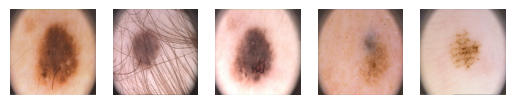

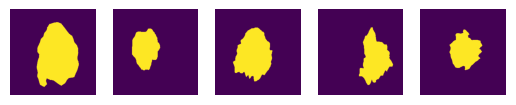

In [7]:
def plotn(n, data, only_mask=False):
    images, masks = data[0], data[1]
    fig, ax = plt.subplots(1, n)
    fig1, ax1 = plt.subplots(1, n)
    for i, (img, mask) in enumerate(zip(images, masks)):
        if i == n:
            break
        if not only_mask:
            ax[i].imshow(torch.permute(img, (1, 2, 0)))
        else:
            ax[i].imshow(img[0])
        ax1[i].imshow(mask[0])
        ax[i].axis('off')
        ax1[i].axis('off')
    plt.show()

plotn(5, train_dataset)

In [11]:
train_dataloader = DataLoader(
    TensorDataset(train_dataset[0], train_dataset[1]),
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    TensorDataset(test_dataset[0], test_dataset[1]),
    batch_size=1,
    shuffle=False
)
dataloaders = (train_dataloader, test_dataloader)

### SegNet
Use standard CNN with conv and poolings in the encoder, and the deconv CNN that includes conv and upsamplings in decoder.

In [12]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_conv0 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), padding=1)
        self.act0 = nn.ReLU()
        self.bn0 = nn.BatchNorm2d(16)
        self.pool0 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv1 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), padding=1)
        self.act1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding=1)
        self.act2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 =  nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding=1)
        self.act3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 =  nn.MaxPool2d(kernel_size=(2,2))

        self.bottleneck_conv = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), padding=1)
        
        self.upsample0 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv0 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=(3,3), padding=1)
        self.dec_act0 = nn.ReLU()
        self.dec_bn0 = nn.BatchNorm2d(128)

        self.upsample1 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv1 =  nn.Conv2d(in_channels=128, out_channels=64, kernel_size=(3,3), padding=1)
        self.dec_act1 = nn.ReLU()
        self.dec_bn1 = nn.BatchNorm2d(64)

        self.upsample2 = nn.UpsamplingBilinear2d(scale_factor=2)
        
        self.dec_conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=(3,3), padding=1)
        self.dec_act2 = nn.ReLU()
        self.dec_bn2 = nn.BatchNorm2d(32)

        self.upsample3 = nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv3 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=(1,1))

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e0 = self.pool0(self.bn0(self.act0(self.enc_conv0(x))))
        e1 = self.pool1(self.bn1(self.act1(self.enc_conv1(e0))))
        e2 = self.pool2(self.bn2(self.act2(self.enc_conv2(e1))))
        e3 = self.pool3(self.bn3(self.act3(self.enc_conv3(e2))))

        b = self.bottleneck_conv(e3)

        d0 = self.dec_bn0(self.dec_act0(self.dec_conv0(self.upsample0(b))))
        d1 = self.dec_bn1(self.dec_act1(self.dec_conv1(self.upsample1(d0))))
        d2 = self.dec_bn2(self.dec_act2(self.dec_conv2(self.upsample2(d1))))
        d3 = self.sigmoid(self.dec_conv3(self.upsample3(d2)))
        return d3

In [14]:
model = SegNet().to(device)
optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
loss_fn = nn.BCEWithLogitsLoss()

In [15]:
def train(dataloaders, model, loss_fn, optimizer, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, labels)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [16]:
train(dataloaders, model, loss_fn, optimizer, epochs, device)

100%|██████████| 30/30 [00:19<00:00,  1.58it/s, train loss:=0.612, test loss:=0.573]


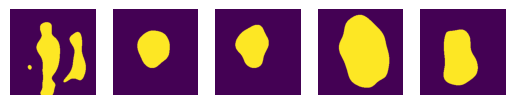

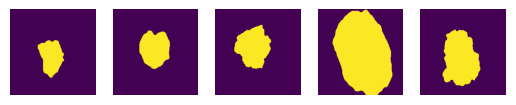

In [17]:
model.eval()
predictions = []
image_mask = []
plots = 5
images, masks = test_dataset[0], test_dataset[1]
for i, (img, mask) in enumerate(zip(images, masks)):
    if i == plots:
        break
    img = img.to(device).unsqueeze(0)
    predictions.append((model(img).detach().cpu()[0] > 0.5).float())
    image_mask.append(mask)
plotn(plots, (predictions, image_mask), only_mask=True)